## VQE on the one-site Hubbard model

H =  (0.5+0j) * (ZZ|[0, 1]) +
(-0.25+0j) * (Z|[0]) +
(-0.25+0j) * (Z|[1])
Qubits:  QReg(q[0]..q[1])


Minimum VQE energy = -0.4999999999999999


Optimal parameter for the converged state, theta_0 =  [3.141592657897627]
parameter dictionary:  {'\\theta_0': 3.141592657897627}
State |00>, amplitude (-1.5230493051388887e-09+0j), probability 2.3196791858840517e-18
State |01>, amplitude -0.7071067811865475j, probability 0.4999999999999999
State |10>, amplitude -0.7071067811865475j, probability 0.4999999999999999
State |11>, amplitude (-1.5230493051388887e-09+0j), probability 2.3196791858840517e-18


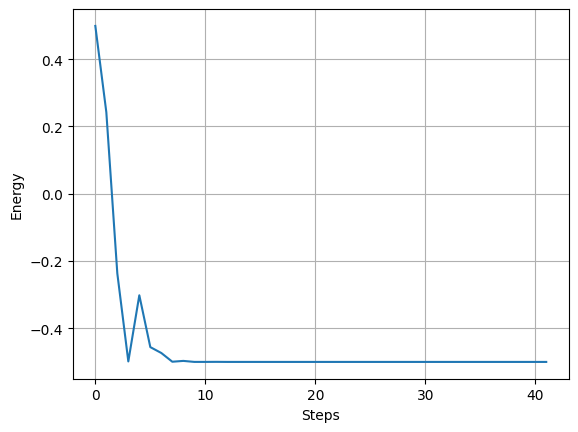

In [5]:
import numpy as np
from qat.lang.AQASM import H, I, X, Y, RX, RY, RZ, CNOT, QRoutine, Program
from qat.core import Observable, Term
from qat.lang import PH
import copy
from qat.plugins import ScipyMinimizePlugin
from qat.qpus import get_default_qpu
from qat.fermion.hamiltonians import make_hubbard_model, SpinHamiltonian
from green_qc import simple_circuit 

# Defining the one-site Hubbard model
U = 2.0
epsilon = -0.5
t_mat = np.ones((1,1))*epsilon
hamiltonian = make_hubbard_model(t_mat, U=U, mu=0)
hamiltonian_spin = hamiltonian.to_spin()
print("H = ", hamiltonian_spin)

# Build the variational circuit for VQE optimization
prog = Program()
reg = prog.qalloc(hamiltonian_spin.nbqbits)
print("Qubits: ", reg)
nparams=1
prog.apply(
    simple_circuit([prog.new_var(float, "\\theta_%s" % i) for i in range(nparams)]),
    reg,
)
circ = prog.to_circ()
circ.display()

# Define the VQE Job
job = circ.to_job(job_type="OBS", observable=hamiltonian_spin, nbshots=0)
theta0 = [0.,0.] # Initialization

# VQE Optimization
optimizer_scipy = ScipyMinimizePlugin(method="Cobyla", x0=theta0, tol=1e-8, options={"maxiter": 1200})
linalg_qpu = get_default_qpu()
qpu = optimizer_scipy | linalg_qpu
result = qpu.submit(job)

print("Minimum VQE energy =", result.value)

converged_params = eval(result.meta_data["parameter_map"])
circ = circ(**converged_params)
circ.display()

# %matplotlib inline
import matplotlib.pyplot as plt

plt.plot(eval(result.meta_data["optimization_trace"]))
plt.xlabel("Steps")
plt.ylabel("Energy")
plt.grid()

print("Optimal parameter for the converged state, theta_0 = ", result.meta_data["parameters"])

print("parameter dictionary: ", converged_params)

# Job
job = circ.to_job(job_type="SAMPLE", nbshots=0)
result_samp = get_default_qpu().submit(job)
for sample in result_samp:
    print("State %s, amplitude %s, probability %s"%(sample.state, sample.amplitude, sample.probability))

# Measure the density
nqubits=2
z_observable = Observable(nqubits, pauli_terms=[Term(1., "Z", [0])])
job = circ.to_job(job_type="OBS", observable=hamiltonian_spin, nbshots=0)
result_z = get_default_qpu().submit(job)


## Measuring the real-time Green function on the prepared ground state of the one-site Hubbard model

/tmp/ipykernel_20075/3892902893.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(tau, GR_bench.real, "k--", lw=4, label=r"$Re[G^R]$ analytical benchmark", color="red")
/tmp/ipykernel_20075/3892902893.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(tau, GR_bench.imag, "k--", lw=4, label=r"$Im[G^R]$ analytical benchmark", color="darkgreen")


Text(0.5, 0, 't')

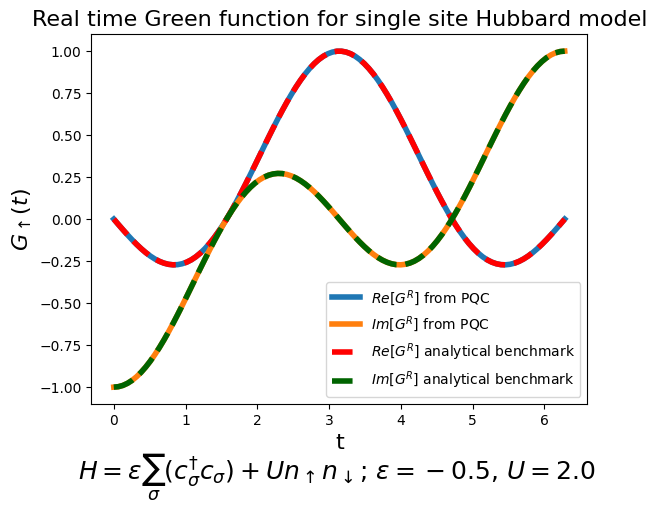

In [14]:
from green_qc import real_time_G_gl

# Grid of real time for measuring the Green function
tau = np.linspace(0,2*np.pi,100)

# epsilon and U are defined above

# Measuring G_greater and G_lesser on a grid of real time
Gg = np.array([real_time_G_gl(tau=tau_loop, nqubits=3, nparams=1, epsilon=epsilon, Greater = True,  U=U, vqe_result=result) for tau_loop in tau])
Gl = np.array([real_time_G_gl(tau=tau_loop, nqubits=3, nparams=1, epsilon=epsilon, Greater = False, U=U, vqe_result=result) for tau_loop in tau])

# Retarded Green function 
G_R=Gg-Gl

# Benchmark from anlytical calculations
GR_bench = -1j*0.5*(np.exp(-1j*(epsilon+U)*tau)+np.exp(-1j*(epsilon)*tau))

# print("Gg = ", Gg)
# print("Gl = ", Gl)
#print(f"G_retarded(t={tau:.2f}) = ", G_R)
    
import matplotlib.pyplot as plt
plt.title("Real time Green function for single site Hubbard model", fontsize=16)
plt.plot(tau, G_R.real, lw=4, label=r"$Re[G^R]$ from PQC")
plt.plot(tau, G_R.imag, lw=4, label=r"$Im[G^R]$ from PQC")
plt.plot(tau, GR_bench.real, "k--", lw=4, label=r"$Re[G^R]$ analytical benchmark", color="red")
plt.plot(tau, GR_bench.imag, "k--", lw=4, label=r"$Im[G^R]$ analytical benchmark", color="darkgreen")
plt.legend()
plt.text(-0.5,-1.55, rf"$H=\epsilon \sum_{{\sigma}}(c_{{\sigma}}^{{\dagger}}c_{{\sigma}}) + Un_{{\uparrow}}n_{{\downarrow}}$; $\epsilon={epsilon:.1f}$, $U={U:.1f}$", fontsize=18)
plt.ylabel(r"$G_{\uparrow}(t)$", fontsize=16) #=-i\left[\langle n_{\downarrow}\rangle e^{-i(\epsilon+U)t} + (1-\langle n_{\downarrow}\rangle) e^{-i \epsilon t}\right]$", fontsize=14)
plt.xlabel("t", fontsize=16)